In [1]:
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt

In [2]:
session = requests.Session()
headers = {
    'User-Agent': 'Mozilla/5.0 (Linux; Android 15; Pixel 9) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/150.0.0.0 Mobile Safari/537.36'
}

In [3]:
df = pd.read_excel('Реестр.xlsx', sheet_name='Лист2',)

In [4]:
df.head()

,№ п/п,Наименование / ФИО,Тип субъекта,Категория,ОГРН,ИНН,Основной вид деятельности,Регион,Район,Город,...,Дата исключения из реестра,Телефон,E-mail,WWW,Наличие лицензий,"Наличие заключенных договоров, контрактов","Производство инновационной, высокотехнологичной продукции",Участие в программах партнерства,Является социальным предприятием,Среднесписочная численность работников за предшествующий календарный год
0,20,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...",Юридическое лицо,Малое предприятие,1025004907080,5038038838,41.20 Строительство жилых и нежилых зданий,50 - Московская область,Пушкино г,NaN,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,36.0
1,52,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Юридическое лицо,Среднее предприятие,1025007270551,5027006369,41.20 Строительство жилых и нежилых зданий,50 - Московская область,NaN,г Дзержинский,...,NaN,NaN,NaN,NaN,Да,Нет,Нет,Нет,Нет,201.0
2,4653,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",Юридическое лицо,Малое предприятие,1021400692048,1414006922,41.20 Строительство жилых и нежилых зданий,77 - г.Москва,NaN,NaN,...,NaN,NaN,NaN,NaN,Да,Нет,Нет,Нет,Нет,35.0
3,4668,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АГРОТЕХИМПОРТ""",Юридическое лицо,Малое предприятие,1043301806415,3327332190,41.20 Строительство жилых и нежилых зданий,33 - Владимирская область,NaN,г Владимир,...,NaN,NaN,NaN,NaN,Да,Нет,Нет,Нет,Нет,52.0
4,4674,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АКС""",Юридическое лицо,Малое предприятие,1027807999988,7816061297,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,NaN,NaN,NaN,NaN,Да,Нет,Нет,Нет,Нет,21.0


In [5]:
company_id = pd.DataFrame()
company_id['inn'] = df['ИНН'].dropna().copy()
company_id['id'] = np.nan
company_id.head(10)

,inn,id
0,5038038838,NaN
1,5027006369,NaN
2,1414006922,NaN
3,3327332190,NaN
4,7816061297,NaN
5,3525048992,NaN
6,3101000612,NaN
7,5902126804,NaN
8,523005733,NaN
9,5009106346,NaN


In [7]:
def parse_id(inn):
    res = session.get(f"https://bo.nalog.gov.ru/advanced-search/organizations/search?query={inn}", headers = headers).json()
    if len(res["content"]) > 0:
        return res["content"][0]["id"]
    else:
        return None

In [8]:
company_id['id'] = company_id['inn'].apply(parse_id)
company_id.head(10)

,inn,id
0,5038038838,5872486.0
1,5027006369,6900709.0
2,1414006922,4980670.0
3,3327332190,3867230.0
4,7816061297,7041303.0
5,3525048992,6840082.0
6,3101000612,7244164.0
7,5902126804,2608351.0
8,523005733,4659067.0
9,5009106346,NaN


In [9]:
company_id = company_id.dropna().astype(int)
company_id

,inn,id
0,5038038838,5872486
1,5027006369,6900709
2,1414006922,4980670
3,3327332190,3867230
4,7816061297,7041303
...,...,...
8922,2301091157,9652105
8923,2301083597,8043846
8924,6504043928,7005901
8925,2002001476,2927552


In [10]:
def pars_org_data(org_id):
    res = session.get(f"https://bo.nalog.gov.ru/nbo/organizations/{org_id}/bfo/", headers = headers).json()
    if len(res) == 0:
        return 0
    else:
        return res

In [11]:
def get_EBITA(res, year):
    years_list = [2025, 2024, 2023, 2022, 2021]
        
    if len(res) == 0:
        return non

    if year not in years_list:
        return 0
        
    year_index = years_list.index(year)
    if year_index >= len(res):
        return 0
        
    data = res[year_index]

    type_corrections = data.get('typeCorrections', [])
    if not type_corrections or len(type_corrections) == 0:
        return 0
        
    correction = type_corrections[0].get('correction', {})
    balance = correction.get('balance', {})
    financial = correction.get('financialResult', {})
    
    current1150 = balance.get('current1150', 0)
    previous1150 = balance.get('previous1150', 0)
        
    current1150 = 0 if pd.isna(current1150) else current1150
    previous1150 = 0 if pd.isna(previous1150) else previous1150
        
    amortization = current1150 - previous1150
    
    EBITA = financial.get('current2400', 0) + financial.get('current2410', 0) + financial.get('current2330', 0) + amortization

    return EBITA

In [12]:
def get_org_EBITA(c_id, years_to_parse):
    res = pars_org_data(c_id)
    return {f'EBITA_{year}': get_EBITA(res, year) for year in years_to_parse}

In [102]:
company_EBITA = pd.DataFrame()
company_EBITA['name'] = df['Наименование / ФИО'].copy()
company_EBITA['city'] = df['Регион'].str.split(' - ').str[1].copy() + ', ' + df['Город'].combine_first(df['Район'].replace(np.nan, ''))
company_EBITA

,name,city
0,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...","Московская область, Пушкино г"
1,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...","Московская область, г Дзержинский"
2,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""","г.Москва,"
3,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АГРОТЕХИМПОРТ""","Владимирская область, г Владимир"
4,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АКС""","г.Санкт-Петербург,"
...,...,...
8922,"СМУ ""МОНОЛИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТ...","Краснодарский край, г Анапа"
8923,"СМУ ""РУСЬ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕН...","Краснодарский край, г Анапа"
8924,СОВМЕСТНОЕ ПРЕДПРИЯТИЕ ОБЩЕСТВО С ОГРАНИЧЕННОЙ...,"Сахалинская область, г Корсаков"
8925,"ФИРМА ""ТЕПЛОСТРОЙПРОЕКТ-С"" ОБЩЕСТВО С ОГРАНИЧЕ...","Чеченская Республика, Ачхой-Мартановский р-н"


In [ ]:
years_to_parse = [2021, 2022, 2023, 2024, 2025]
results = company_id['id'].apply(get_org_EBITA, years_to_parse=years_to_parse)
ebita_df = pd.DataFrame(results.tolist())
ebita_df

In [42]:
company_EBITA = pd.concat([company_EBITA, ebita_df], axis=1)
company_EBITA

,name,EBITA_2021,EBITA_2022,EBITA_2023,EBITA_2024,EBITA_2025
0,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...",-106204.0,-2632.0,-80487.0,-5837.0,68775.0
1,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",72459.0,169330.0,-331305.0,148582.0,878836.0
2,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",-422277.0,1760.0,2695.0,40228.0,15513.0
3,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АГРОТЕХИМПОРТ""",34360.0,26469.0,92944.0,69922.0,158698.0
4,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АКС""",4460.0,-2662.0,-584.0,21316.0,-349.0
...,...,...,...,...,...,...
8922,"СМУ ""МОНОЛИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТ...",NaN,NaN,NaN,NaN,NaN
8923,"СМУ ""РУСЬ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕН...",NaN,NaN,NaN,NaN,NaN
8924,СОВМЕСТНОЕ ПРЕДПРИЯТИЕ ОБЩЕСТВО С ОГРАНИЧЕННОЙ...,NaN,NaN,NaN,NaN,NaN
8925,"ФИРМА ""ТЕПЛОСТРОЙПРОЕКТ-С"" ОБЩЕСТВО С ОГРАНИЧЕ...",NaN,NaN,NaN,NaN,NaN


In [43]:
company_EBITA = company_EBITA.dropna()
company_EBITA

,name,EBITA_2021,EBITA_2022,EBITA_2023,EBITA_2024,EBITA_2025
0,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...",-106204.0,-2632.0,-80487.0,-5837.0,68775.0
1,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",72459.0,169330.0,-331305.0,148582.0,878836.0
2,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",-422277.0,1760.0,2695.0,40228.0,15513.0
3,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АГРОТЕХИМПОРТ""",34360.0,26469.0,92944.0,69922.0,158698.0
4,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АКС""",4460.0,-2662.0,-584.0,21316.0,-349.0
...,...,...,...,...,...,...
8837,ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ УПРАВ...,-18673.0,-35527.0,-87702.0,-24430.0,2794.0
8838,ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ УПРАВ...,-22188.0,-39441.0,-29609.0,-25296.0,69516.0
8839,ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ УПРАВ...,121502.0,38881.0,-513174.0,-151461.0,-16205.0
8840,ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ УПРАВ...,-1175.0,3095.0,2134.0,-6130.0,-965.0


In [49]:
company_EBITA_sortEBITA = company_EBITA.sort_values(['EBITA_2025','EBITA_2024','EBITA_2023','EBITA_2022','EBITA_2021'],ascending=False)
company_EBITA_sortEBITA
#.reset_index(drop=True)

,name,EBITA_2021,EBITA_2022,EBITA_2023,EBITA_2024,EBITA_2025
2283,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ИНКЕ...",1012961.0,61583.0,4261.0,23719.0,7061288.0
7595,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""УРАЛ...",0.0,0.0,0.0,-10972.0,6041650.0
7492,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""УДС-...",0.0,253582.0,1032553.0,2997677.0,4571887.0
5362,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СПЕЦ...",-1335209.0,905415.0,1502585.0,-907394.0,3273561.0
6935,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТРО...",12317.0,22056.0,236411.0,236846.0,3247384.0
...,...,...,...,...,...,...
7823,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЦВЕТ...",0.0,73139.0,239741.0,-19100.0,-1779738.0
5322,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СПАР...",-949041.0,143722.0,685440.0,7853405.0,-1899458.0
7579,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""УРАЛ...",14596.0,85570.0,22702.0,348742.0,-2859603.0
2134,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ИВДО...",1457.0,-11398.0,-391.0,-940.0,-2981463.0


In [46]:
def EBITA_growth (period):
    company_EBITA_growth = company_EBITA.copy()

    N = period
    year_old = 2025 - N  
    year_new = 2025
    EBITA_old = f'EBITA_{year_old}'
    EBITA_new = f'EBITA_{year_new}'
    
    company_EBITA_growth['growth_pct'] = (
    (company_EBITA_growth[EBITA_new] - company_EBITA_growth[EBITA_old]) / company_EBITA_growth[EBITA_old].replace(0, np.nan) * 100)
    company_EBITA_growth = company_EBITA_growth.replace([np.inf, -np.inf], np.nan).dropna()
    company_EBITA_growth['growth_pct'] = company_EBITA_growth['growth_pct'].astype(int)


    return company_EBITA_growth['growth_pct'], N

In [47]:
def create_plot(EBITA_growth, period):
    plt.figure(figsize=(14, 8))

    N = period
    year_old = 2025 - N  
    year_new = 2025
    
    bins = np.arange(-100, 110, 10)
    plt.hist(EBITA_growth, bins=bins, edgecolor='black')
    
    
    plt.xlabel('Процент роста чистой прибыли (EBITA), %', fontsize=14)
    plt.xticks(np.arange(-100, 110, 10))
    plt.ylabel('Количество компаний', fontsize=14)
    plt.title(f'Распределение компаний по росту чистой прибыли\n{year_old} → {year_new} (период: {N})', fontsize=16)
    plt.grid(True)
    plt.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Нулевой рост')
    plt.legend()
    
    mean_growth = EBITA_growth.median()
    plt.axvline(x=mean_growth, color='green', linestyle='-', linewidth=2, label=f'Медианный рост: {mean_growth:.1f}%')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

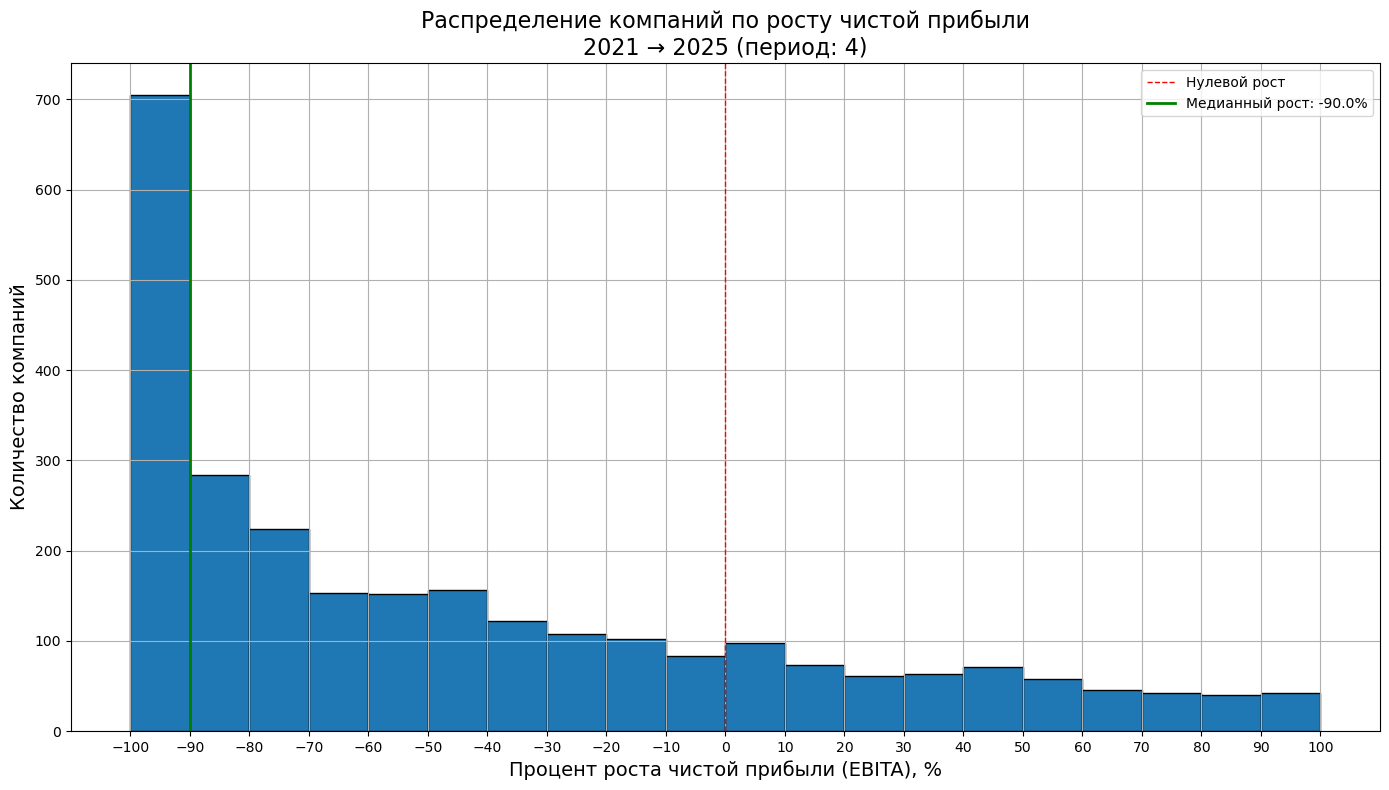

In [48]:
create_plot(*EBITA_growth(4))

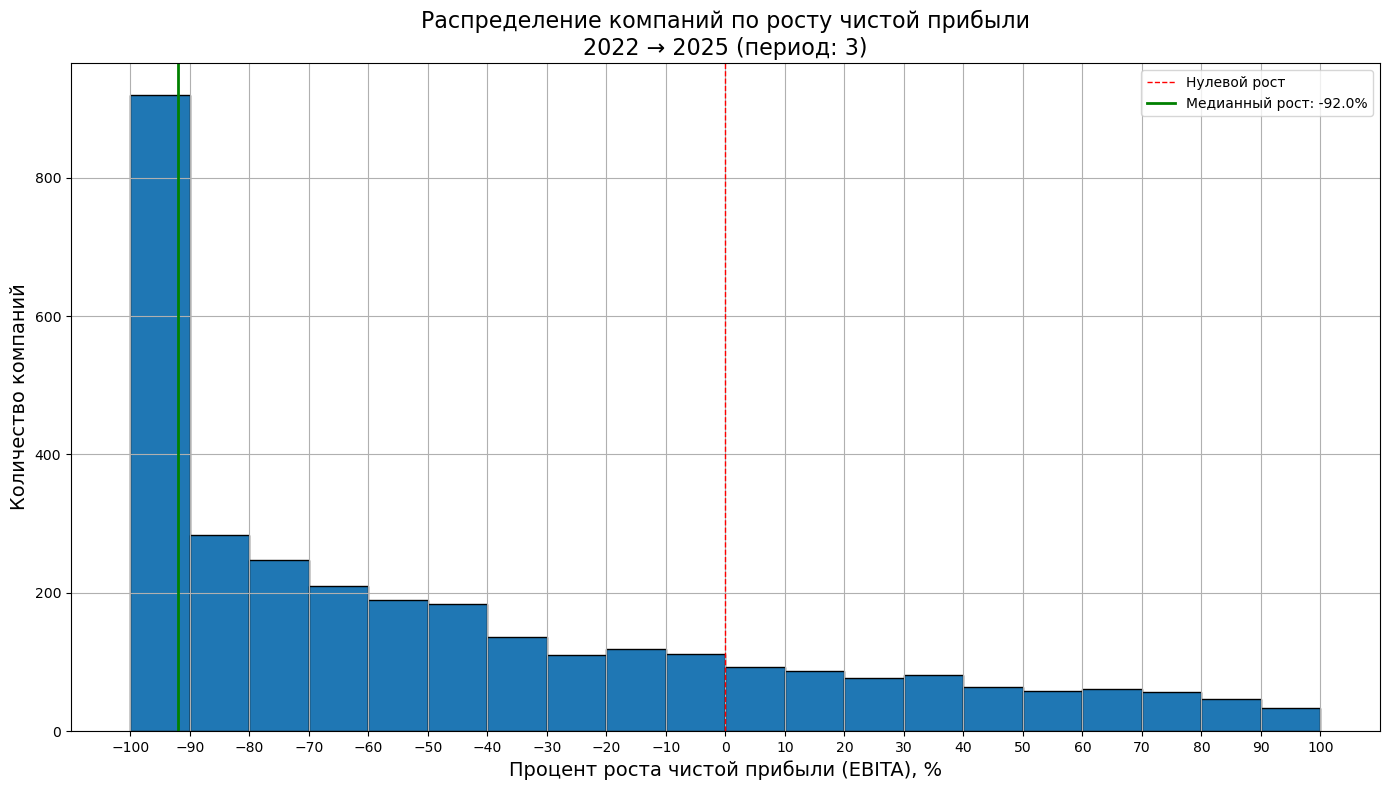

In [31]:
create_plot(*EBITA_growth(3))

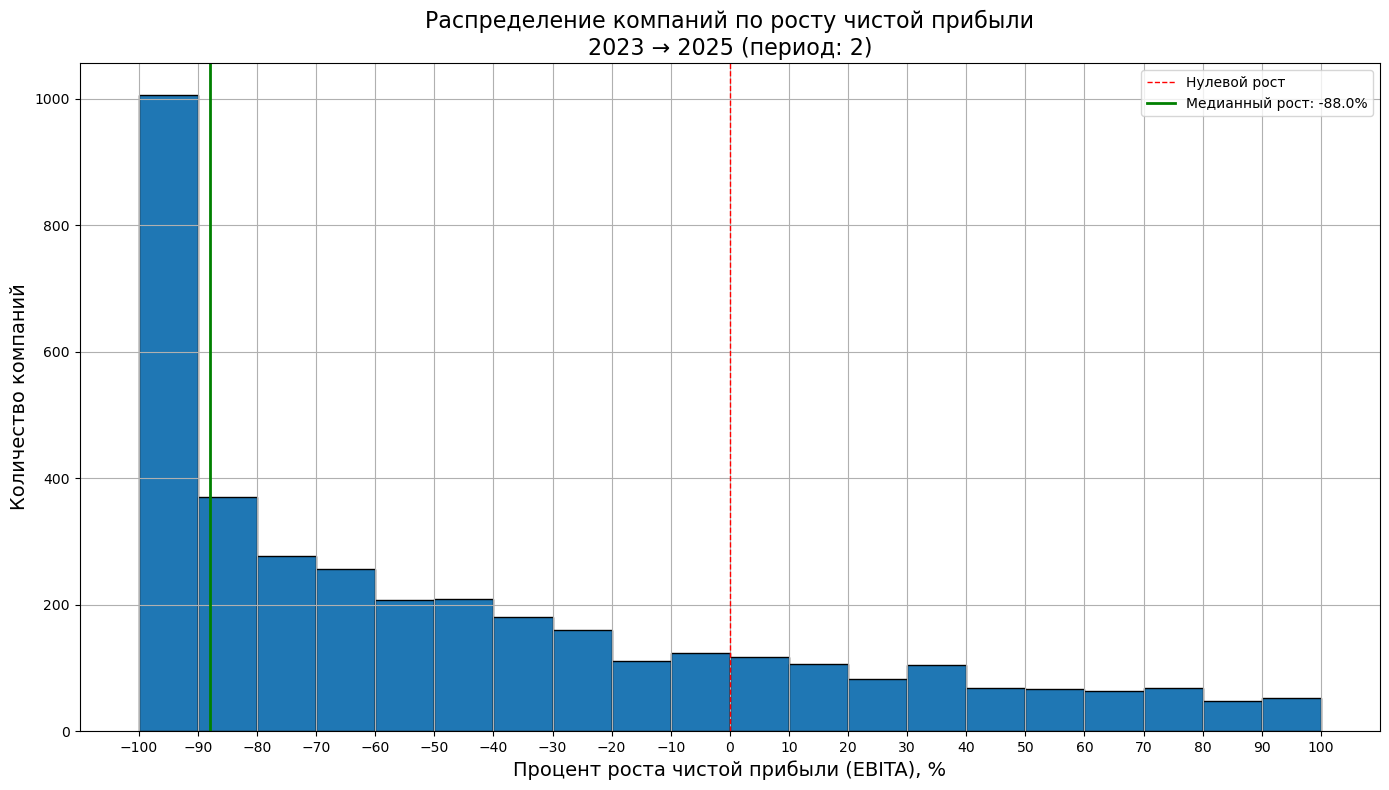

In [32]:
create_plot(*EBITA_growth(2))

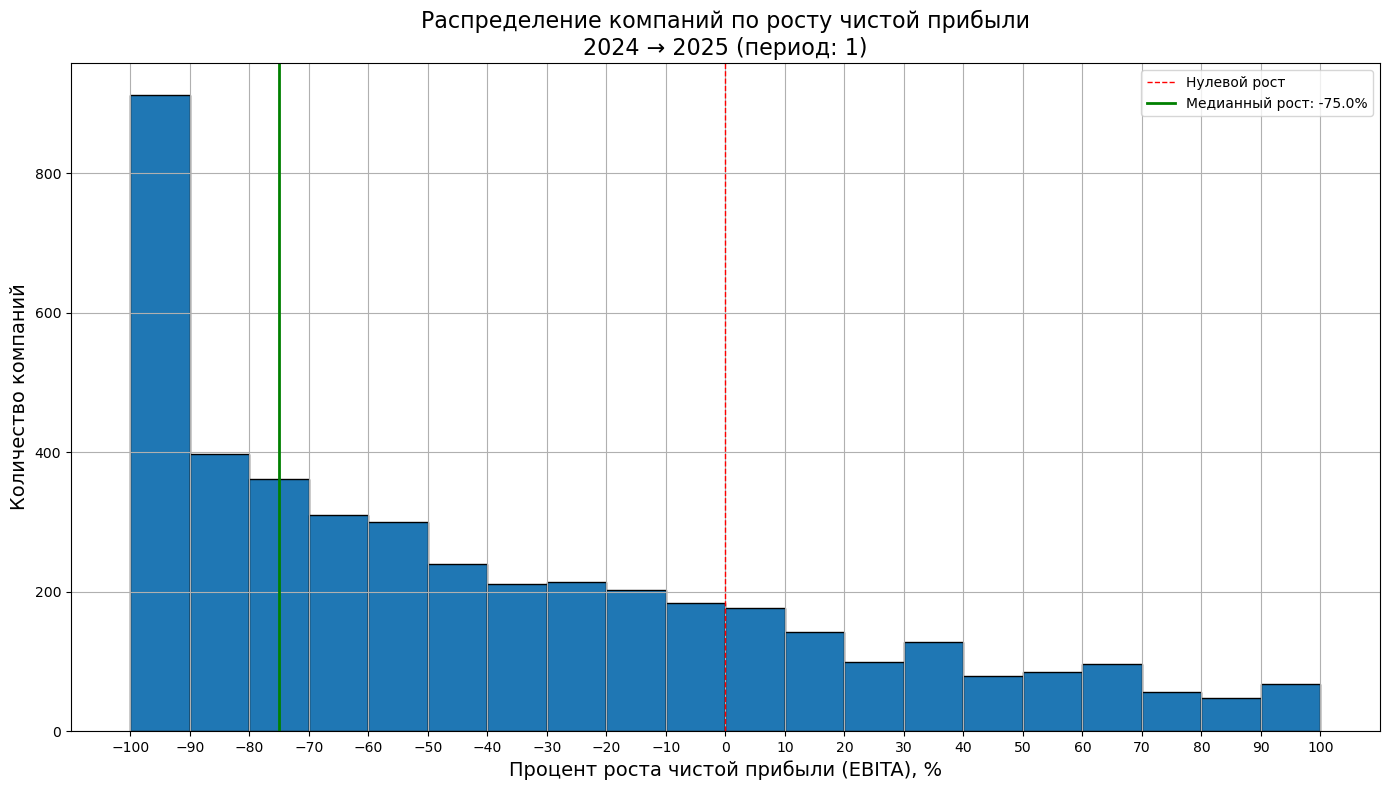

In [33]:
create_plot(*EBITA_growth(1))

На основе графиков, где основным показателем является медианный рост, видно, что более половины компаний потеряла около 90 процентов своей чистой прибыли и этот спад прибыли сохраняется минимум на протяжениии четырёх лет.

In [60]:
from geopy.geocoders import Nominatim
import time

In [103]:
geolocator = Nominatim(user_agent="Mozilla/5.0 (Linux; Android 15; Pixel 9) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/150.0.0.0 Mobile Safari/537.36", timeout=10)
#df_city = company_EBITA_sortEBITA.head(5).copy()
df_city = company_EBITA.head(20).copy()
df_city['lat'] = None
df_city['lon'] = None

df_city

,name,city,lat,lon
0,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...","Московская область, Пушкино г",None,None
1,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...","Московская область, г Дзержинский",None,None
2,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""","г.Москва,",None,None
3,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АГРОТЕХИМПОРТ""","Владимирская область, г Владимир",None,None
4,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АКС""","г.Санкт-Петербург,",None,None
5,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АКЦИОНЕРНАЯ ПРОИЗВОДСТВЕ...","Вологодская область, г Вологда",None,None
6,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АЛЕКСЕЕВСКАЯ ПЕРЕДВИЖНАЯ...","Белгородская область, г Алексеевка",None,None
7,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АМБЕР-СТРОЙСЕРВИС""","Пермский край, г Пермь",None,None
8,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АМИРУС""","Республика Дагестан, Магарамкентский р-н",None,None
9,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АРОВАНА""","Московская область, г Домодедово",None,None


In [104]:
for city in df_city['city'].unique():
    try:
        location = geolocator.geocode(city)
        if location:
            df_city.loc[df_city['city'] == city, 'lat'] = location.latitude
            df_city.loc[df_city['city'] == city, 'lon'] = location.longitude
        else:
            print(f"Город '{city}' не найден.")
        time.sleep(1)
    except Exception as e:
        print(f"Ошибка для города '{city}': {e}")

Город 'Белгородская область, г Алексеевка' не найден.
Город 'Республика Карелия, г Беломорск' не найден.


In [105]:
import plotly.express as px

In [111]:
df_city_clean = pd.DataFrame()
df_city_clean = df_city.dropna().copy()

fig = px.scatter_map(df_city_clean, lat="lat", lon="lon", hover_name="name", hover_data = "city", zoom=3, height=500)
fig.update_layout(map_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

ValueError: Value of 'hover_data_0' is not the name of a column in 'data_frame'. Expected one of ['lat', 'lon', 'name'] but received: city

In [ ]:
conda install -c conda-forge jupyterlab jupyterlab-git